## 1. Import Libraries

In [68]:
import numpy as np

import pandas as pd

import sklearn
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics.pairwise import rbf_kernel
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import (
    Pipeline,
    FeatureUnion
)
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import (
    OneHotEncoder,
    OrdinalEncoder,
    StandardScaler,
    MinMaxScaler,
    PowerTransformer,
    FunctionTransformer
)

from feature_engine.encoding import (
    RareLabelEncoder,
    MeanEncoder,
    CountFrequencyEncoder
)
from feature_engine.datetime import DatetimeFeatures
from feature_engine.outliers import Winsorizer
from feature_engine.selection import SelectBySingleFeaturePerformance

import matplotlib.pyplot as plt

import warnings

## 2. Display Settings

In [2]:
pd.set_option("display.max_columns", None)
sklearn.set_config(transform_output="pandas")
warnings.filterwarnings("ignore")

## 3. Read the Data

In [3]:
path = r"../data/train.csv"

train = pd.read_csv(path)
train

,airline,date_of_journey,source,destination,dep_time,arrival_time,duration,total_stops,additional_info,price
0,Jet Airways,2019-03-21,Banglore,Delhi,08:55:00,19:10:00,615,1.0,In-flight meal not included,7832
1,Jet Airways,2019-03-27,Delhi,Cochin,17:30:00,04:25:00,655,1.0,In-flight meal not included,6540
2,Goair,2019-03-09,Banglore,Delhi,11:40:00,14:35:00,175,0.0,No Info,7305
3,Air India,2019-06-12,Kolkata,Banglore,09:25:00,18:30:00,545,1.0,No Info,8366
4,Jet Airways,2019-03-12,Banglore,Delhi,22:55:00,07:40:00,525,1.0,In-flight meal not included,11087
...,...,...,...,...,...,...,...,...,...,...
6690,Jet Airways,2019-03-21,Delhi,Cochin,10:45:00,18:50:00,1925,2.0,No Info,11093
6691,Air India,2019-05-01,Kolkata,Banglore,09:25:00,18:30:00,545,1.0,No Info,8891
6692,Jet Airways,2019-06-01,Delhi,Cochin,14:00:00,19:00:00,300,1.0,In-flight meal not included,10262
6693,Air Asia,2019-06-24,Delhi,Cochin,07:55:00,13:25:00,330,1.0,No Info,6152


In [4]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 6695 entries, 0 to 6694
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   airline          6695 non-null   str    
 1   date_of_journey  6695 non-null   str    
 2   source           6695 non-null   str    
 3   destination      6695 non-null   str    
 4   dep_time         6695 non-null   str    
 5   arrival_time     6695 non-null   str    
 6   duration         6695 non-null   int64  
 7   total_stops      6694 non-null   float64
 8   additional_info  6695 non-null   str    
 9   price            6695 non-null   int64  
dtypes: float64(1), int64(2), str(7)
memory usage: 523.2 KB


In [5]:
X_train = train.drop(columns="price")
y_train = train.price.copy()

## 4. Transformation Operations

### 4.1 airline

- imputation
- group rare labels
- one-hot encoding

In [6]:
air_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("grouper", RareLabelEncoder(tol=0.1, n_categories=2, replace_with="Other")),
    ("encoder", OneHotEncoder(sparse_output=False, handle_unknown="ignore"))
])

air_transformer.fit_transform(X_train.loc[:,["airline"]])

,airline_Air India,airline_Indigo,airline_Jet Airways,airline_Multiple Carriers,airline_Other
0,0.0,0.0,1.0,0.0,0.0
1,0.0,0.0,1.0,0.0,0.0
2,0.0,0.0,0.0,0.0,1.0
3,1.0,0.0,0.0,0.0,0.0
4,0.0,0.0,1.0,0.0,0.0
...,...,...,...,...,...
6690,0.0,0.0,1.0,0.0,0.0
6691,1.0,0.0,0.0,0.0,0.0
6692,0.0,0.0,1.0,0.0,0.0
6693,0.0,0.0,0.0,0.0,1.0


### 4.2 date_of_journey

- date-time features
- min-max scaling

In [7]:
feature_to_extract = ["month", "day_of_week", "weekend"]

In [8]:
doj_transformer = Pipeline(steps=[
    ("dt_features", DatetimeFeatures(features_to_extract=feature_to_extract, yearfirst=True)),
    ("scaler", MinMaxScaler())
])

doj_transformer.fit_transform(X_train.loc[:,["date_of_journey"]])

,date_of_journey_month,date_of_journey_day_of_week,date_of_journey_weekend
0,0.000000,0.500000,0.0
1,0.000000,0.333333,0.0
2,0.000000,0.833333,1.0
3,1.000000,0.333333,0.0
4,0.000000,0.166667,0.0
...,...,...,...
6690,0.000000,0.500000,0.0
6691,0.666667,0.333333,0.0
6692,1.000000,0.833333,1.0
6693,1.000000,0.000000,0.0


### 4.3 source & destination 

- group rare labels
- mean encoding / target mean encoding
- power transformer

- is north city

In [9]:
location_pipe1 = Pipeline(steps=[
    ("grouper", RareLabelEncoder(tol=0.1, n_categories=2, replace_with="Other")),
    ("encoder", MeanEncoder()),
    ("power_transform", PowerTransformer())
])
location_pipe1.fit_transform(X_train.loc[:,["source","destination"]], y_train)

,source,destination
0,-0.857930,-0.857930
1,1.065418,1.065418
2,-0.857930,-0.857930
3,-0.203927,-0.203927
4,-0.857930,-0.857930
...,...,...
6690,1.065418,1.065418
6691,-0.203927,-0.203927
6692,1.065418,1.065418
6693,1.065418,1.065418


In [10]:
np.union1d(
    X_train.source.unique(),
    X_train.destination.unique()
)

array(['Banglore', 'Chennai', 'Cochin', 'Delhi', 'Hyderabad', 'Kolkata',
       'Mumbai'], dtype=object)

In [11]:
def is_north(X):
    columns = X.columns.to_list()
    north_cities = ["Delhi", "Kolkata", "Mumbai"]

    return (
        X
        .assign(**{
            f"{col}_is_north": X.loc[:, col].isin(north_cities).astype(int)
            for col in columns
        })
        .drop(columns=columns)
    )

FunctionTransformer(func=is_north).fit_transform(X_train.loc[:,["source","destination"]])

,source_is_north,destination_is_north
0,0,1
1,1,0
2,0,1
3,1,0
4,0,1
...,...,...
6690,1,0
6691,1,0
6692,1,0
6693,1,0


In [12]:
location_transformer = FeatureUnion(transformer_list=[
    ("part1", location_pipe1),
    ("part2", FunctionTransformer(func=is_north))
])

location_transformer.fit_transform(X_train.loc[:,["source","destination"]], y_train)

,source,destination,source_is_north,destination_is_north
0,-0.857930,-0.857930,0,1
1,1.065418,1.065418,1,0
2,-0.857930,-0.857930,0,1
3,-0.203927,-0.203927,1,0
4,-0.857930,-0.857930,0,1
...,...,...,...,...
6690,1.065418,1.065418,1,0
6691,-0.203927,-0.203927,1,0
6692,1.065418,1.065418,1,0
6693,1.065418,1.065418,1,0


### 4.4 dep_time & arrival_time

pipe1:

- date-time features
- min-max scaling


pipe2:

- part of day
- count endoding
- min-max scaling


In [13]:
X_train.loc[:,["dep_time", "arrival_time"]]

,dep_time,arrival_time
0,08:55:00,19:10:00
1,17:30:00,04:25:00
2,11:40:00,14:35:00
3,09:25:00,18:30:00
4,22:55:00,07:40:00
...,...,...
6690,10:45:00,18:50:00
6691,09:25:00,18:30:00
6692,14:00:00,19:00:00
6693,07:55:00,13:25:00


In [14]:
time_pipe1 = Pipeline(steps=[
    ("dt_features", DatetimeFeatures(features_to_extract=["hour", "minute"])),
    ("scaler", MinMaxScaler())
])

time_pipe1.fit_transform(X_train.loc[:,["dep_time", "arrival_time"]])

,dep_time_hour,dep_time_minute,arrival_time_hour,arrival_time_minute
0,0.347826,1.000000,0.826087,0.181818
1,0.739130,0.545455,0.173913,0.454545
2,0.478261,0.727273,0.608696,0.636364
3,0.391304,0.454545,0.782609,0.545455
4,0.956522,1.000000,0.304348,0.727273
...,...,...,...,...
6690,0.434783,0.818182,0.782609,0.909091
6691,0.391304,0.454545,0.782609,0.545455
6692,0.608696,0.000000,0.826087,0.000000
6693,0.304348,1.000000,0.565217,0.454545


In [15]:
def part_of_day(X, morning=4, noon=12, eve=16, night=20):
    columns = X.columns.to_list()
    X_temp = X.assign(**{
        col: pd.to_datetime(X.loc[:,col]).dt.hour
        for col in columns
    })

    return (
        X_temp
        .assign(**{
            f"{col}_part_of_day": np.select(
                [X_temp.loc[:,col].between(morning, noon, inclusive="left"),
                 X_temp.loc[:,col].between(noon, eve, inclusive="left"),
                 X_temp.loc[:,col].between(eve, night, inclusive="left")],
                ["morning",
                 "afternoon",
                 "evening"],
                default="night"
            )
            for col in columns
        })
        .drop(columns=columns)
    )

FunctionTransformer(func=part_of_day).fit_transform(X_train.loc[:,["dep_time", "arrival_time"]])

,dep_time_part_of_day,arrival_time_part_of_day
0,morning,evening
1,evening,morning
2,morning,afternoon
3,morning,evening
4,night,morning
...,...,...
6690,morning,evening
6691,morning,evening
6692,afternoon,evening
6693,morning,afternoon


In [16]:
time_pipe2 = Pipeline(steps=[
    ("part", FunctionTransformer(func=part_of_day)),
    ("encoder", CountFrequencyEncoder()),
    ("scaler", MinMaxScaler())
])

time_pipe2.fit_transform(X_train.loc[:,["dep_time", "arrival_time"]])

,dep_time_part_of_day,arrival_time_part_of_day
0,1.000000,0.667335
1,0.202685,0.952906
2,1.000000,0.000000
3,1.000000,0.667335
4,0.174101,0.952906
...,...,...
6690,1.000000,0.667335
6691,1.000000,0.667335
6692,0.000000,0.667335
6693,1.000000,0.000000


In [17]:
time_transformer = FeatureUnion(transformer_list=[
    ("part1", time_pipe1),
    ("part2", time_pipe2)
])

time_transformer.fit_transform(X_train.loc[:,["dep_time", "arrival_time"]])

,dep_time_hour,dep_time_minute,arrival_time_hour,arrival_time_minute,dep_time_part_of_day,arrival_time_part_of_day
0,0.347826,1.000000,0.826087,0.181818,1.000000,0.667335
1,0.739130,0.545455,0.173913,0.454545,0.202685,0.952906
2,0.478261,0.727273,0.608696,0.636364,1.000000,0.000000
3,0.391304,0.454545,0.782609,0.545455,1.000000,0.667335
4,0.956522,1.000000,0.304348,0.727273,0.174101,0.952906
...,...,...,...,...,...,...
6690,0.434783,0.818182,0.782609,0.909091,1.000000,0.667335
6691,0.391304,0.454545,0.782609,0.545455,1.000000,0.667335
6692,0.608696,0.000000,0.826087,0.000000,0.000000,0.667335
6693,0.304348,1.000000,0.565217,0.454545,1.000000,0.000000


## 4.5 duration

- capping by quantiles (Winsorizer)
- imputation
---

- duration categories
- ordinal encoding (ordinal column; specific categories)
---

- RBF percentiles similarity (RBF kernel)
    ```
    Compute the rbf (gaussian) kernel between X and Y
    K(x,y) = exp(-gamma ||x-y||^2)
    for each pair of rows x in X and y in Y.
    ```
- power transformer
---

- over arbitrary minutes
- standard scaling

In [18]:
X_train.duration

0        615
1        655
2        175
3        545
4        525
        ... 
6690    1925
6691     545
6692     300
6693     330
6694    1265
Name: duration, Length: 6695, dtype: int64

In [19]:
def duration_category(X, short=180, med=400):
    return (
        X
        .assign(
            duration_cat = np.select(
                [X.duration.lt(short),
                 X.duration.between(short, med, inclusive="left")],
                ["short","medium"],
                default="long"
            )
        )
        .drop(columns="duration")
    )

In [20]:
def is_over(X, value=1000):
    return (
        X
        .assign(**{
            f"durationis_over_{value}": X.duration.ge(value).astype(int)
        })
        .drop(columns="duration")
    )

In [24]:
class RBFPercentileSimilarity(BaseEstimator, TransformerMixin):

    def __init__(self, variables=None, percentiles=[0.25, 0.5, 0.75], gamma=0.1):
        self.variables = variables
        self.percentiles = percentiles
        self.gamma = gamma
    
    def fit(self, X, y=None):
        if not self.variables:
            self.variables = X.select_dtypes(include="number").columns.to_list()

        self.reference_values_ = {
            col: X.loc[:,col].quantile(self.percentiles).values.reshape(-1,1)
            for col in self.variables
        }

        return self

    def transform(self, X):
        objects = []
        for col in self.variables:
            columns = [f"{col}_rbf_{int(percentile*100)}" for percentile in self.percentiles]
            obj = pd.DataFrame(
                data = rbf_kernel(X.loc[:,[col]], Y=self.reference_values_[col], gamma=self.gamma),
                columns=columns
            )
            objects.append(obj)
            
        return pd.concat(objects, axis=1)

In [25]:
RBFPercentileSimilarity().fit_transform(X_train.loc[:,["duration"]])

,duration_rbf_25,duration_rbf_50,duration_rbf_75
0,0.000000,0.000000e+00,0.0
1,0.000000,0.000000e+00,0.0
2,0.082085,0.000000e+00,0.0
3,0.000000,6.293989e-54,0.0
4,0.000000,1.691898e-10,0.0
...,...,...,...
6690,0.000000,0.000000e+00,0.0
6691,0.000000,6.293989e-54,0.0
6692,0.000000,0.000000e+00,0.0
6693,0.000000,0.000000e+00,0.0


In [33]:
duration_pipe1 = Pipeline(steps=[
    ("rbf", RBFPercentileSimilarity()),
    ("scaler", PowerTransformer())
])

duration_pipe2 = Pipeline(steps=[
    ("cat", FunctionTransformer(func=duration_category)),
    ("encoder", OrdinalEncoder(categories=[["short", "medium", "long"]]))
])

duration_union = FeatureUnion(transformer_list=[
    ("part1", duration_pipe1),
    ("part2", duration_pipe2),
    ("part3", FunctionTransformer(func=is_over)),
    ("part4", StandardScaler())
])

duration_transformer = Pipeline(steps=[
    ("outliers", Winsorizer(capping_method="iqr", fold=1.5)),
    ("imputer", SimpleImputer(strategy="median")),
    ("union", duration_union)
])

In [34]:
duration_transformer.fit_transform(X_train.loc[:, ["duration"]])

,duration_rbf_25,duration_rbf_50,duration_rbf_75,duration_cat,durationis_over_1000,duration
0,-0.364262,-0.106983,-0.101517,2.0,0,-0.033916
1,-0.364262,-0.106983,-0.101517,2.0,0,0.046422
2,2.373008,-0.106983,-0.101517,0.0,0,-0.917631
3,-0.364262,-0.106983,-0.101517,2.0,0,-0.174507
4,-0.364262,-0.106983,-0.101517,2.0,0,-0.214676
...,...,...,...,...,...,...
6690,-0.364262,-0.106983,-0.101517,2.0,1,2.597145
6691,-0.364262,-0.106983,-0.101517,2.0,0,-0.174507
6692,-0.364262,-0.106983,-0.101517,1.0,0,-0.666576
6693,-0.364262,-0.106983,-0.101517,1.0,0,-0.606322


### 4.6 total_stops

- imputation
- is direct flight

In [40]:
X_train.loc[2534]

airline             Air India
date_of_journey    2019-05-06
source                  Delhi
destination            Cochin
dep_time             09:45:00
arrival_time         09:25:00
duration                 1420
total_stops               NaN
additional_info       No Info
Name: 2534, dtype: object

In [47]:
def is_direct(X):
    return X.assign(is_direct_flight=X.total_stops.eq(0).astype(int))

total_stops_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("", FunctionTransformer(func=is_direct))
])

In [52]:
total_stops_transformer.fit_transform(X_train.loc[:,["total_stops"]])

,total_stops,is_direct_flight
0,1.0,0
1,1.0,0
2,0.0,1
3,1.0,0
4,1.0,0
...,...,...
6690,2.0,0
6691,1.0,0
6692,1.0,0
6693,1.0,0


### 4.7 additional_info

- imputation
- group rare labels
- one-hot encoding
- have info

In [53]:
X_train.additional_info

0       In-flight meal not included
1       In-flight meal not included
2                           No Info
3                           No Info
4       In-flight meal not included
                   ...             
6690                        No Info
6691                        No Info
6692    In-flight meal not included
6693                        No Info
6694                 1 Long layover
Name: additional_info, Length: 6695, dtype: str

In [54]:
info_pipe1 = Pipeline(steps=[
    ("group", RareLabelEncoder(tol=0.1, n_categories=2, replace_with="Other")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

info_pipe1.fit_transform(X_train.loc[:,["additional_info"]])

,additional_info_In-flight meal not included,additional_info_No Info,additional_info_Other
0,1.0,0.0,0.0
1,1.0,0.0,0.0
2,0.0,1.0,0.0
3,0.0,1.0,0.0
4,1.0,0.0,0.0
...,...,...,...
6690,0.0,1.0,0.0
6691,0.0,1.0,0.0
6692,1.0,0.0,0.0
6693,0.0,1.0,0.0


In [63]:
def have_info(X):
    return X.assign(additional_info=X.additional_info.ne("No Info").astype(int))

In [64]:
info_union = FeatureUnion(transformer_list=[
    ("part1", info_pipe1),
    ("part2", FunctionTransformer(func=have_info))
])

In [65]:
info_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="constant", fill_value="unknowwn")),
    ("union", info_union)
])

In [66]:
info_transformer.fit_transform(X_train.loc[:,["additional_info"]])

,additional_info_In-flight meal not included,additional_info_No Info,additional_info_Other,additional_info
0,1.0,0.0,0.0,1
1,1.0,0.0,0.0,1
2,0.0,1.0,0.0,0
3,0.0,1.0,0.0,0
4,1.0,0.0,0.0,1
...,...,...,...,...
6690,0.0,1.0,0.0,0
6691,0.0,1.0,0.0,0
6692,1.0,0.0,0.0,1
6693,0.0,1.0,0.0,0


### 4.8 Column Transformer

In [67]:
column_transformer = ColumnTransformer(transformers=[
    ("airline", air_transformer, ["airline"] ),
    ("doj", doj_transformer, ["date_of_journey"]),
    ("location", location_transformer, ["source", "destination"]),
    ("time", time_transformer, ["dep_time", "arrival_time"]),
    ("dur", duration_transformer, ["duration"]),
    ("stops", total_stops_transformer, ["total_stops"]),
    ("info", info_transformer, ["additional_info"])
], remainder="passthrough")

column_transformer.fit_transform(X_train, y_train)

,airline__airline_Air India,airline__airline_Indigo,airline__airline_Jet Airways,airline__airline_Multiple Carriers,airline__airline_Other,doj__date_of_journey_month,doj__date_of_journey_day_of_week,doj__date_of_journey_weekend,location__source,location__destination,location__source_is_north,location__destination_is_north,time__dep_time_hour,time__dep_time_minute,time__arrival_time_hour,time__arrival_time_minute,time__dep_time_part_of_day,time__arrival_time_part_of_day,dur__duration_rbf_25,dur__duration_rbf_50,dur__duration_rbf_75,dur__duration_cat,dur__durationis_over_1000,dur__duration,stops__total_stops,stops__is_direct_flight,info__additional_info_In-flight meal not included,info__additional_info_No Info,info__additional_info_Other,info__additional_info
0,0.0,0.0,1.0,0.0,0.0,0.000000,0.500000,0.0,-0.857930,-0.857930,0,1,0.347826,1.000000,0.826087,0.181818,1.000000,0.667335,-0.364262,-0.106983,-0.101517,2.0,0,-0.033916,1.0,0,1.0,0.0,0.0,1
1,0.0,0.0,1.0,0.0,0.0,0.000000,0.333333,0.0,1.065418,1.065418,1,0,0.739130,0.545455,0.173913,0.454545,0.202685,0.952906,-0.364262,-0.106983,-0.101517,2.0,0,0.046422,1.0,0,1.0,0.0,0.0,1
2,0.0,0.0,0.0,0.0,1.0,0.000000,0.833333,1.0,-0.857930,-0.857930,0,1,0.478261,0.727273,0.608696,0.636364,1.000000,0.000000,2.373008,-0.106983,-0.101517,0.0,0,-0.917631,0.0,1,0.0,1.0,0.0,0
3,1.0,0.0,0.0,0.0,0.0,1.000000,0.333333,0.0,-0.203927,-0.203927,1,0,0.391304,0.454545,0.782609,0.545455,1.000000,0.667335,-0.364262,-0.106983,-0.101517,2.0,0,-0.174507,1.0,0,0.0,1.0,0.0,0
4,0.0,0.0,1.0,0.0,0.0,0.000000,0.166667,0.0,-0.857930,-0.857930,0,1,0.956522,1.000000,0.304348,0.727273,0.174101,0.952906,-0.364262,-0.106983,-0.101517,2.0,0,-0.214676,1.0,0,1.0,0.0,0.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6690,0.0,0.0,1.0,0.0,0.0,0.000000,0.500000,0.0,1.065418,1.065418,1,0,0.434783,0.818182,0.782609,0.909091,1.000000,0.667335,-0.364262,-0.106983,-0.101517,2.0,1,2.597145,2.0,0,0.0,1.0,0.0,0
6691,1.0,0.0,0.0,0.0,0.0,0.666667,0.333333,0.0,-0.203927,-0.203927,1,0,0.391304,0.454545,0.782609,0.545455,1.000000,0.667335,-0.364262,-0.106983,-0.101517,2.0,0,-0.174507,1.0,0,0.0,1.0,0.0,0
6692,0.0,0.0,1.0,0.0,0.0,1.000000,0.833333,1.0,1.065418,1.065418,1,0,0.608696,0.000000,0.826087,0.000000,0.000000,0.667335,-0.364262,-0.106983,-0.101517,1.0,0,-0.666576,1.0,0,1.0,0.0,0.0,1
6693,0.0,0.0,0.0,0.0,1.0,1.000000,0.000000,0.0,1.065418,1.065418,1,0,0.304348,1.000000,0.565217,0.454545,1.000000,0.000000,-0.364262,-0.106983,-0.101517,1.0,0,-0.606322,1.0,0,0.0,1.0,0.0,0


## 5. Feature Selection

- selection by performance of each individual feature

In [69]:
estimator = RandomForestRegressor(n_estimators=10, max_depth=3, random_state=42)

selector = SelectBySingleFeaturePerformance(
    estimator=estimator,
    scoring="r2",
    threshold=0.1
)

## 6. Putting it all together

In [70]:
preprocessor = Pipeline(steps=[
    ("ct", column_transformer),
    ("selector", selector)
])

In [71]:
preprocessor.fit_transform(X_train, y_train)

,airline__airline_Indigo,airline__airline_Jet Airways,airline__airline_Other,location__source,location__destination,dur__duration_rbf_25,dur__duration_cat,dur__durationis_over_1000,dur__duration,stops__total_stops,stops__is_direct_flight
0,0.0,1.0,0.0,-0.857930,-0.857930,-0.364262,2.0,0,-0.033916,1.0,0
1,0.0,1.0,0.0,1.065418,1.065418,-0.364262,2.0,0,0.046422,1.0,0
2,0.0,0.0,1.0,-0.857930,-0.857930,2.373008,0.0,0,-0.917631,0.0,1
3,0.0,0.0,0.0,-0.203927,-0.203927,-0.364262,2.0,0,-0.174507,1.0,0
4,0.0,1.0,0.0,-0.857930,-0.857930,-0.364262,2.0,0,-0.214676,1.0,0
...,...,...,...,...,...,...,...,...,...,...,...
6690,0.0,1.0,0.0,1.065418,1.065418,-0.364262,2.0,1,2.597145,2.0,0
6691,0.0,0.0,0.0,-0.203927,-0.203927,-0.364262,2.0,0,-0.174507,1.0,0
6692,0.0,1.0,0.0,1.065418,1.065418,-0.364262,1.0,0,-0.666576,1.0,0
6693,0.0,0.0,1.0,1.065418,1.065418,-0.364262,1.0,0,-0.606322,1.0,0


## 7. Visualizations

In [72]:
feature_performances = preprocessor.named_steps["selector"].feature_performance_
feature_performances

{'airline__airline_Air India': np.float64(0.0016858488187393068),
 'airline__airline_Indigo': np.float64(0.12827620333701603),
 'airline__airline_Jet Airways': np.float64(0.19341654864699923),
 'airline__airline_Multiple Carriers': np.float64(0.01885367626900632),
 'airline__airline_Other': np.float64(0.11819934849670959),
 'doj__date_of_journey_month': np.float64(0.08907386829479753),
 'doj__date_of_journey_day_of_week': np.float64(0.004664789869158821),
 'doj__date_of_journey_weekend': np.float64(-0.0009403217440686618),
 'location__source': np.float64(0.1267120700518518),
 'location__destination': np.float64(0.1267120700518518),
 'location__source_is_north': np.float64(0.029331367522183977),
 'location__destination_is_north': np.float64(0.029331367522183977),
 'time__dep_time_hour': np.float64(0.007541502467654985),
 'time__dep_time_minute': np.float64(0.03749304101660215),
 'time__arrival_time_hour': np.float64(0.07867962012854395),
 'time__arrival_time_minute': np.float64(0.032296

In [73]:
sorted_feat_imp = dict(sorted(feature_performances.items(), key=lambda val: val[1]))
sorted_feat_imp

{'time__dep_time_part_of_day': np.float64(-0.0013166458315723162),
 'info__additional_info_No Info': np.float64(-0.001132211161403977),
 'info__additional_info': np.float64(-0.001132211161403977),
 'doj__date_of_journey_weekend': np.float64(-0.0009403217440686618),
 'dur__duration_rbf_75': np.float64(0.0007341117000158048),
 'info__additional_info_In-flight meal not included': np.float64(0.0014426619953507396),
 'airline__airline_Air India': np.float64(0.0016858488187393068),
 'doj__date_of_journey_day_of_week': np.float64(0.004664789869158821),
 'dur__duration_rbf_50': np.float64(0.005866872514748896),
 'time__dep_time_hour': np.float64(0.007541502467654985),
 'info__additional_info_Other': np.float64(0.01760748529752132),
 'airline__airline_Multiple Carriers': np.float64(0.01885367626900632),
 'location__source_is_north': np.float64(0.029331367522183977),
 'location__destination_is_north': np.float64(0.029331367522183977),
 'time__arrival_time_part_of_day': np.float64(0.0313709099091

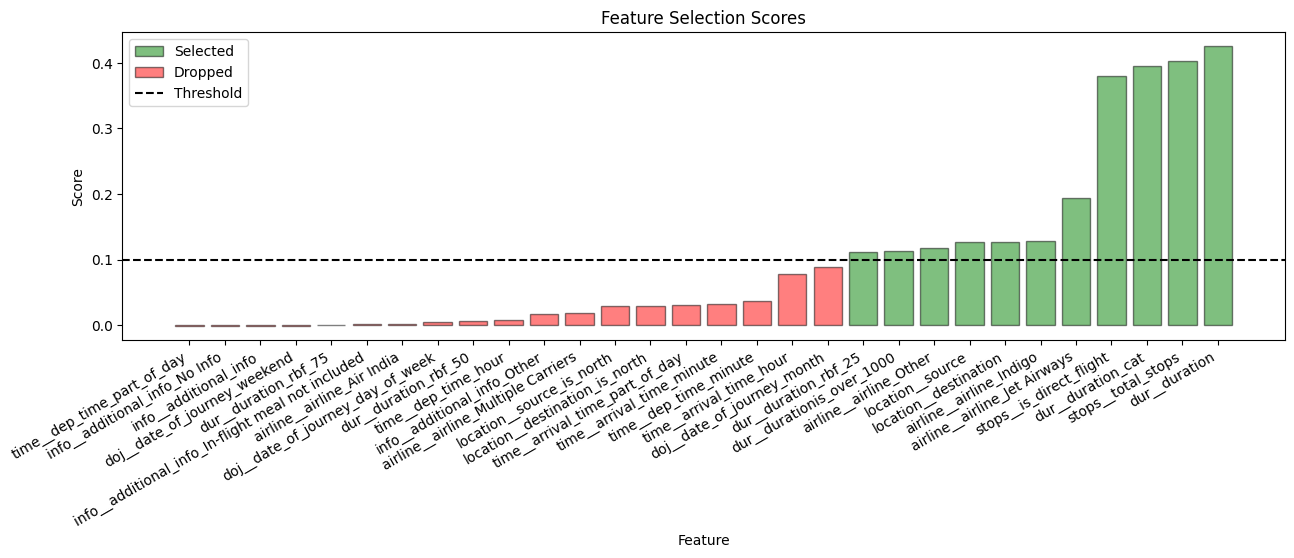

In [74]:
THRESHOLD = 0.1

selected_bar = None
dropped_bar = None
colors = ["red" if score < THRESHOLD else "green" for score in sorted_feat_imp.values()]


fig, ax = plt.subplots(figsize=(15, 4)) 

for i, (feature, score) in enumerate(sorted_feat_imp.items()):
	params = dict(
		x=i,
		height=score,
		edgecolor="black",
		alpha=0.5
	)
	
	if score < THRESHOLD:
		bar = ax.bar(
			color="red",
			**params
		)
		if not dropped_bar:
			dropped_bar = bar[0]
	else:
		bar = ax.bar(
			color="green",
			**params
		)
		if not selected_bar:
			selected_bar = bar[0]

thresh_line = ax.axhline(
	y=0.1,
	color="black",
	linestyle="--"
)

ax.set_xticks(
	ticks=range(len(sorted_feat_imp)),
	labels=list(sorted_feat_imp.keys()),
	rotation=30,
	ha="right"
)

ax.set(
	xlabel="Feature",
	ylabel="Score",
	title="Feature Selection Scores"
)

ax.legend(
	handles=[selected_bar, dropped_bar, thresh_line],
	labels=["Selected", "Dropped", "Threshold"],
	loc="upper left"
)

plt.show()


- the dataset went upto 30 columns after feature engineering
- the feature selection algorithm selected 13 features out of that